### **Projeto de PCD - Contagem de ORFs e zonas possivelmente codificáveis**

#### Entrada ---> duas (ou por enquanto, uma) sequências de DNA

In [8]:
import matplotlib.pyplot as plt

In [9]:
# Retirando sequências de arquivos .txt (por enquanto são sequências de exemplo)
seq_1 = "ATGCGTACGTTAGCTAGGCTAACGTAGCTAGCTTACGATCGGATCGTACGTAGCTAGTCCGATGCTAGCTAGGATCCGTAGCTAGCTAGTACGATCGTA"
seq_2 = "CGTATGCTAGCTAGTACGATGCGTAGCTAGGCTAGCTTACGATCGTAGCTAGTCCGATGCGTACGATCGTAGCTAGCTAGGATCGTACGATGCTAGCTA"

In [10]:
def transcricao(sequencia):
    
    """Transcreve a sequência de DNA em uma sequência de RNA.

    Args:
        Uma sequência de DNA em formato de string.

    Returns:
        Uma string representando a sequência de DNA
        agora transcrita em RNA.
    """

    rna = sequencia.replace("T", "U")

    return rna

In [16]:
def encontra_orfs(sequencia):
    """Encontra os ORFs que a sequência de DNA de entrada tem.
    
    Args:
        Uma sequência de DNA em formato de string.
        
    Returns: 
        Um dicionário representando todos os ORFs 
        possíveis contidos na sequência de entrada.
    """

    assert isinstance(sequencia, str), "A entrada admite apenas argumentos do tipo string!"

    sequencia = transcricao(sequencia)
    # Cria um dicionário vazio para a adição de ORFs
    orfs = dict()
    contador = 1
    i = 0

    # Define quais são as terminações que uma ORF deve ter
    paradas = ["UAA", "UAG", "UGA"]

    # Percorre toda a sequência, de 3 em 3, em busca de um códon "AUG"
    for i in range(len(sequencia)-2):
        if sequencia[i:i+3] == "AUG":

            # Percorre a sequência buscando códons de parada
            for j in range(i, len(sequencia)-2, 3):
                codon = sequencia[j:j+3]
                if codon in paradas:

                    # Armazena o trecho entre o códon inicio e o códon parada
                    orf = sequencia[i:j+3]

                    # Armazena os ORFs dentro de um dicionário
                    orfs[f"ORF_{contador}"] = orf
                    contador += 1
                    break

    return orfs

In [20]:
def orfs_tamanho(sequencia):

    tamanhos = {"0 à 30":0, "31 à 45":0, "46 à 120":0, "121 à 500":0, "Maior que 500":0}

    orfs = encontra_orfs(sequencia)
    
    for orf, gene in orfs.items():
        tamanho_gene = (len(gene)-3)/3

        if tamanho_gene <= 30:
            tamanhos["0 à 30"] += 1

        if tamanho_gene > 30 and tamanho_gene <= 45:
            tamanhos["31 à 45"] += 1

        if tamanho_gene > 46 and tamanho_gene <= 120:
            tamanhos["46 à 120"] += 1

        if tamanho_gene > 121 and tamanho_gene <= 500:
            tamanhos["121 à 500"] += 1

        if tamanho_gene > 500:
            tamanhos["Maior que 500"] += 1

    return tamanhos

In [12]:
def compara_orfs(sequencia_1, sequencia_2):

    # Transcreve as sequencias de DNA em RNA
    rna_1 = transcricao(sequencia_1)
    rna_2 = transcricao(sequencia_2)

    # Encontra os ORFs que cada sequência possui
    orfs_1 = encontra_orfs(rna_1)
    orfs_2 = encontra_orfs(rna_2)

    # Transforma em gráfico
    sequencias = ["Sequência 1", "Sequência 2"]
    quantidade_orfs = [len(orfs_1), len(orfs_2)]

    plt.bar(sequencias, quantidade_orfs)
    
    plt.title("Quantidade de ORFs")
    plt.xlabel("Sequencias")
    plt.ylabel("Quantidade")

    return plt.show()

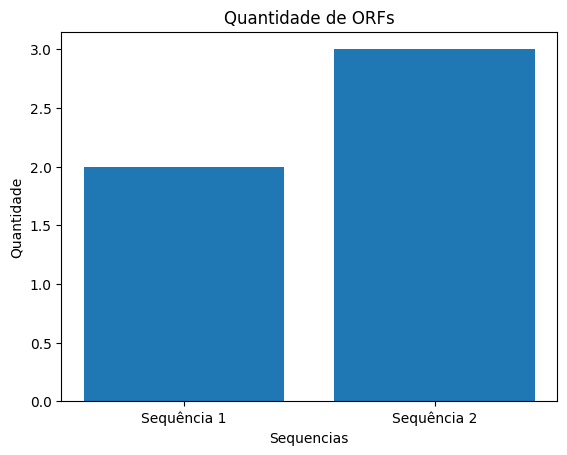

In [21]:
compara_orfs(seq_1, seq_2)